# Trader Performance vs Market Sentiment Analysis
##  Data Science Intern Assignment -- kumar

**Objective**: Analyze how Bitcoin market sentiment (Fear/Greed Index) relates to trader behavior and performance on Hyperliquid. Uncover patterns that could inform smarter trading strategies.

**Structure**:
- **Part A**: Data Preparation (load, clean, merge, key metrics)
- **Part B**: Analysis (Fear vs Greed performance, behavioral changes, segmentation)
- **Part C**: Actionable Strategies
- **Bonus**: Predictive Model + Trader Clustering

## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, silhouette_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
import os

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
os.makedirs('output', exist_ok=True)
print("All libraries imported successfully.")

All libraries imported successfully.


---
# PART A - Data Preparation
## 2. Load and Inspect Datasets

In [2]:
# Load both datasets
sentiment_df = pd.read_csv('data/sentiment_data.csv')
trader_df = pd.read_csv('data/trader_data.csv')

print("=" * 60)
print("SENTIMENT DATASET")
print("=" * 60)
print(f"Shape: {sentiment_df.shape[0]} rows x {sentiment_df.shape[1]} columns")
print(f"Columns: {sentiment_df.columns.tolist()}")
print(f"\nMissing values:\n{sentiment_df.isnull().sum()}")
print(f"\nDuplicates: {sentiment_df.duplicated().sum()}")
print(f"\nSample rows:")
display(sentiment_df.head())

print("\n" + "=" * 60)
print("TRADER DATASET")
print("=" * 60)
print(f"Shape: {trader_df.shape[0]} rows x {trader_df.shape[1]} columns")
print(f"Columns: {trader_df.columns.tolist()}")
print(f"\nMissing values:\n{trader_df.isnull().sum()}")
print(f"\nDuplicates: {trader_df.duplicated().sum()}")
print(f"\nSample rows:")
display(trader_df.head())

SENTIMENT DATASET
Shape: 2644 rows x 4 columns
Columns: ['timestamp', 'value', 'classification', 'date']

Missing values:
timestamp         0
value             0
classification    0
date              0
dtype: int64

Duplicates: 0

Sample rows:


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05



TRADER DATASET
Shape: 211224 rows x 16 columns
Columns: ['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']

Missing values:
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Duplicates: 0

Sample rows:


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


## 3. Convert Timestamps & Align Datasets
Parse timestamps, extract dates, create binary sentiment grouping, and merge on date.

In [3]:
# Parse timestamps
sentiment_df['date'] = pd.to_datetime(sentiment_df['date'])
trader_df['datetime'] = pd.to_datetime(trader_df['Timestamp IST'], format='%d-%m-%Y %H:%M')
trader_df['date'] = pd.to_datetime(trader_df['datetime'].dt.date)

# Binary sentiment grouping
sentiment_df['sentiment_binary'] = sentiment_df['classification'].apply(
    lambda x: 'Fear' if 'Fear' in x else ('Greed' if 'Greed' in x else 'Neutral')
)

print(f"Trader date range: {trader_df['date'].min().date()} to {trader_df['date'].max().date()}")
print(f"Sentiment date range: {sentiment_df['date'].min().date()} to {sentiment_df['date'].max().date()}")
print(f"\nSentiment distribution:")
display(sentiment_df['classification'].value_counts().to_frame())

# Merge on date (inner join)
merged_df = trader_df.merge(
    sentiment_df[['date', 'value', 'classification', 'sentiment_binary']],
    on='date', how='inner'
)
print(f"\nMerged dataset: {merged_df.shape[0]} rows ({merged_df['date'].nunique()} unique dates, {merged_df['Account'].nunique()} traders)")

Trader date range: 2023-05-01 to 2025-05-01
Sentiment date range: 2018-02-01 to 2025-05-02

Sentiment distribution:


,count
classification,
Fear,781
Greed,633
Extreme Fear,508
Neutral,396
Extreme Greed,326



Merged dataset: 211218 rows (479 unique dates, 32 traders)


## 4. Feature Engineering: Create Key Metrics
Compute daily PnL, win rate, trade frequency, long/short ratio, position sizes at both daily-aggregate and per-trader levels.

In [4]:
# Trade-level flags
merged_df['is_close'] = merged_df['Closed PnL'] != 0
merged_df['is_win'] = merged_df['Closed PnL'] > 0
merged_df['is_long'] = merged_df['Direction'].str.contains('Long|Buy', case=False, na=False)
merged_df['is_short'] = merged_df['Direction'].str.contains('Short|Sell', case=False, na=False)

# Daily PnL per trader
daily_trader = merged_df.groupby(['date', 'Account', 'sentiment_binary', 'classification', 'value']).agg(
    daily_pnl=('Closed PnL', 'sum'),
    total_fees=('Fee', 'sum'),
    num_trades=('Trade ID', 'count'),
    num_wins=('is_win', 'sum'),
    num_closes=('is_close', 'sum'),
    avg_trade_size=('Size USD', 'mean'),
    total_volume=('Size USD', 'sum'),
    num_longs=('is_long', 'sum'),
    num_shorts=('is_short', 'sum'),
).reset_index()

daily_trader['net_pnl'] = daily_trader['daily_pnl'] - daily_trader['total_fees']
daily_trader['win_rate'] = (daily_trader['num_wins'] / daily_trader['num_closes'].replace(0, np.nan)) * 100
daily_trader['long_short_ratio'] = daily_trader['num_longs'] / daily_trader['num_shorts'].replace(0, np.nan)

# Daily aggregate (all traders combined)
daily_agg = merged_df.groupby(['date', 'sentiment_binary', 'classification', 'value']).agg(
    total_pnl=('Closed PnL', 'sum'),
    total_fees=('Fee', 'sum'),
    num_trades=('Trade ID', 'count'),
    num_wins=('is_win', 'sum'),
    num_closes=('is_close', 'sum'),
    avg_trade_size=('Size USD', 'mean'),
    total_volume=('Size USD', 'sum'),
    num_longs=('is_long', 'sum'),
    num_shorts=('is_short', 'sum'),
    unique_traders=('Account', 'nunique'),
).reset_index()

daily_agg['net_pnl'] = daily_agg['total_pnl'] - daily_agg['total_fees']
daily_agg['win_rate'] = (daily_agg['num_wins'] / daily_agg['num_closes'].replace(0, np.nan)) * 100
daily_agg['long_short_ratio'] = daily_agg['num_longs'] / daily_agg['num_shorts'].replace(0, np.nan)

# Per-account overall stats
account_stats = merged_df.groupby('Account').agg(
    total_pnl=('Closed PnL', 'sum'), total_fees=('Fee', 'sum'),
    num_trades=('Trade ID', 'count'), num_wins=('is_win', 'sum'),
    num_closes=('is_close', 'sum'), avg_trade_size=('Size USD', 'mean'),
    total_volume=('Size USD', 'sum'), num_longs=('is_long', 'sum'),
    num_shorts=('is_short', 'sum'), active_days=('date', 'nunique'),
).reset_index()

account_stats['net_pnl'] = account_stats['total_pnl'] - account_stats['total_fees']
account_stats['win_rate'] = (account_stats['num_wins'] / account_stats['num_closes'].replace(0, np.nan)) * 100
account_stats['long_short_ratio'] = account_stats['num_longs'] / account_stats['num_shorts'].replace(0, np.nan)
account_stats['avg_daily_trades'] = account_stats['num_trades'] / account_stats['active_days']
account_stats['pnl_per_trade'] = account_stats['total_pnl'] / account_stats['num_trades']

print(f"Daily trader-level: {daily_trader.shape[0]} rows")
print(f"Daily aggregate: {daily_agg.shape[0]} rows")
print(f"Account stats: {account_stats.shape[0]} traders")

# Key metrics summary by sentiment
summary_table = daily_agg.groupby('sentiment_binary').agg(
    avg_daily_pnl=('total_pnl', 'mean'), avg_daily_trades=('num_trades', 'mean'),
    avg_trade_size=('avg_trade_size', 'mean'), avg_win_rate=('win_rate', 'mean'),
    avg_volume=('total_volume', 'mean'), avg_ls_ratio=('long_short_ratio', 'mean'),
    count_days=('date', 'count'),
).round(2)

print("\nKey Metrics Summary by Sentiment:")
display(summary_table)
summary_table.to_csv('output/key_metrics_by_sentiment.csv')

Daily trader-level: 2340 rows
Daily aggregate: 479 rows
Account stats: 32 traders

Key Metrics Summary by Sentiment:


,avg_daily_pnl,avg_daily_trades,avg_trade_size,avg_win_rate,avg_volume,avg_ls_ratio,count_days
sentiment_binary,,,,,,,
Fear,39012.05,792.73,6199.96,84.51,5693419.54,3.67,105
Greed,15847.88,294.12,5872.03,84.19,1345432.11,1.98,307
Neutral,19297.32,562.48,7157.53,79.38,2690180.05,2.31,67


---
# PART B - Analysis

## 5. B1: Performance Differences — Fear vs Greed Days
Does PnL, win rate, or drawdown differ between Fear and Greed market regimes?

Fear vs Greed PnL -- Mann-Whitney U: stat=17796.00, p=0.1109
  Fear days avg PnL:    $39,012.05
  Greed days avg PnL:   $15,847.88
  Neutral days avg PnL: $19,297.32

Fear vs Greed Win Rate -- Mann-Whitney U: stat=11780.50, p=0.5870
  Fear avg win rate:  84.51%
  Greed avg win rate: 84.19%

Drawdown proxy (worst daily PnL):
  Fear:  $-122,672.00
  Greed: $-419,020.23


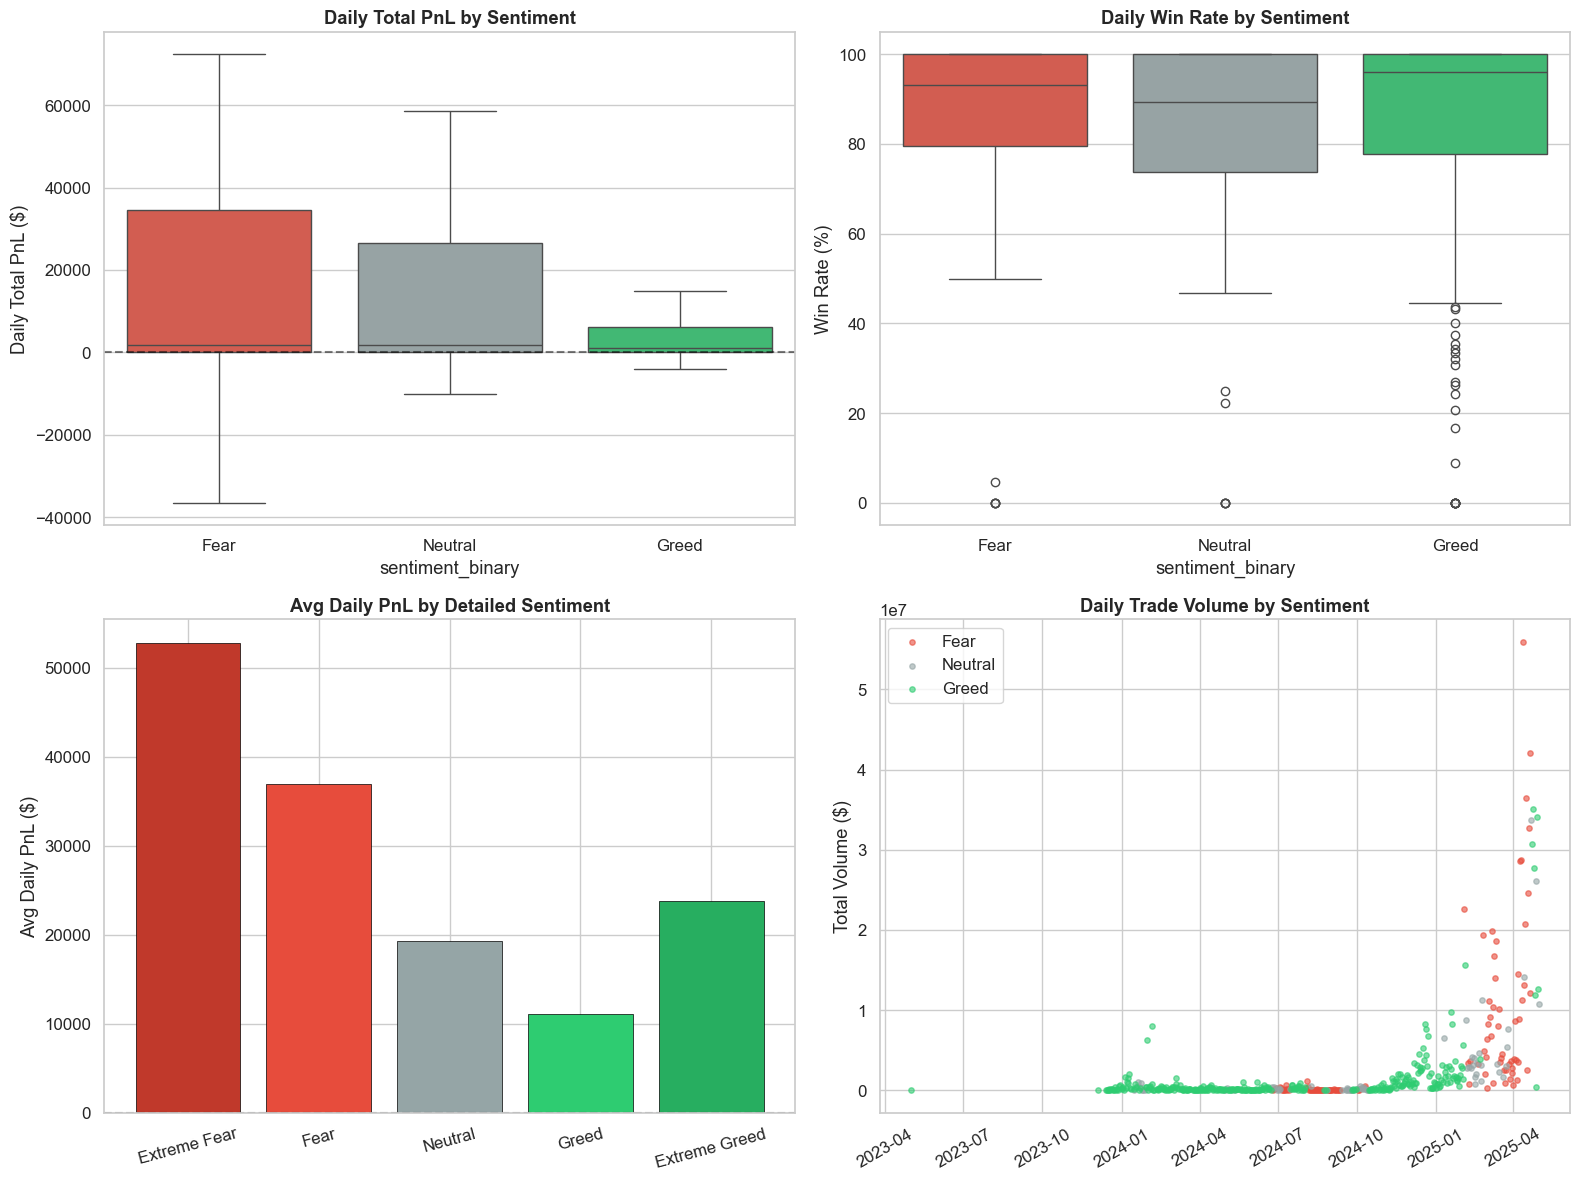

In [5]:
# Statistical tests: Fear vs Greed PnL
fear_pnl = daily_agg[daily_agg['sentiment_binary'] == 'Fear']['total_pnl']
greed_pnl = daily_agg[daily_agg['sentiment_binary'] == 'Greed']['total_pnl']
neutral_pnl = daily_agg[daily_agg['sentiment_binary'] == 'Neutral']['total_pnl']

t_stat, p_value = stats.mannwhitneyu(fear_pnl, greed_pnl, alternative='two-sided')
print(f"Fear vs Greed PnL -- Mann-Whitney U: stat={t_stat:.2f}, p={p_value:.4f}")
print(f"  Fear days avg PnL:    ${fear_pnl.mean():,.2f}")
print(f"  Greed days avg PnL:   ${greed_pnl.mean():,.2f}")
print(f"  Neutral days avg PnL: ${neutral_pnl.mean():,.2f}")

fear_wr = daily_agg[daily_agg['sentiment_binary'] == 'Fear']['win_rate'].dropna()
greed_wr = daily_agg[daily_agg['sentiment_binary'] == 'Greed']['win_rate'].dropna()
t_wr, p_wr = stats.mannwhitneyu(fear_wr, greed_wr, alternative='two-sided')
print(f"\nFear vs Greed Win Rate -- Mann-Whitney U: stat={t_wr:.2f}, p={p_wr:.4f}")
print(f"  Fear avg win rate:  {fear_wr.mean():.2f}%")
print(f"  Greed avg win rate: {greed_wr.mean():.2f}%")

fear_max_loss = fear_pnl.min()
greed_max_loss = greed_pnl.min()
print(f"\nDrawdown proxy (worst daily PnL):")
print(f"  Fear:  ${fear_max_loss:,.2f}")
print(f"  Greed: ${greed_max_loss:,.2f}")

# --- CHART 1: PnL Distribution by Sentiment ---
order = ['Fear', 'Neutral', 'Greed']
colors = {'Fear': '#e74c3c', 'Neutral': '#95a5a6', 'Greed': '#2ecc71'}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.boxplot(data=daily_agg, x='sentiment_binary', y='total_pnl', order=order,
            palette=colors, ax=axes[0, 0], showfliers=False)
axes[0, 0].set_title('Daily Total PnL by Sentiment', fontweight='bold')
axes[0, 0].set_ylabel('Daily Total PnL ($)')
axes[0, 0].axhline(y=0, color='black', linestyle='--', alpha=0.5)

sns.boxplot(data=daily_agg, x='sentiment_binary', y='win_rate', order=order,
            palette=colors, ax=axes[0, 1])
axes[0, 1].set_title('Daily Win Rate by Sentiment', fontweight='bold')
axes[0, 1].set_ylabel('Win Rate (%)')

detail_order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
detail_colors = ['#c0392b', '#e74c3c', '#95a5a6', '#2ecc71', '#27ae60']
detail_pnl = daily_agg.groupby('classification')['total_pnl'].mean().reindex(detail_order)
axes[1, 0].bar(detail_order, detail_pnl.values, color=detail_colors, edgecolor='black', linewidth=0.5)
axes[1, 0].set_title('Avg Daily PnL by Detailed Sentiment', fontweight='bold')
axes[1, 0].set_ylabel('Avg Daily PnL ($)')
axes[1, 0].axhline(y=0, color='black', linestyle='--', alpha=0.5)
axes[1, 0].tick_params(axis='x', rotation=15)

daily_sorted = daily_agg.sort_values('date')
for sent in order:
    subset = daily_sorted[daily_sorted['sentiment_binary'] == sent]
    axes[1, 1].scatter(subset['date'], subset['total_volume'], c=colors[sent], label=sent, alpha=0.6, s=15)
axes[1, 1].set_title('Daily Trade Volume by Sentiment', fontweight='bold')
axes[1, 1].set_ylabel('Total Volume ($)')
axes[1, 1].legend()
axes[1, 1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('output/chart1_pnl_by_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. B2: Behavioral Changes Based on Sentiment
Do traders change behavior (trade frequency, position sizes, long/short bias) on Fear vs Greed days?

Behavioral Metrics by Sentiment:


,avg_trades_per_day,avg_trade_size,avg_ls_ratio,avg_volume
sentiment_binary,,,,
Fear,792.73,6199.96,3.67,5693419.54
Neutral,562.48,7157.53,2.31,2690180.05
Greed,294.12,5872.03,1.98,1345432.11


Trade Frequency -- Mann-Whitney U: stat=19131.00, p=0.0042
Long/Short Ratio -- Mann-Whitney U: stat=14150.00, p=0.000024


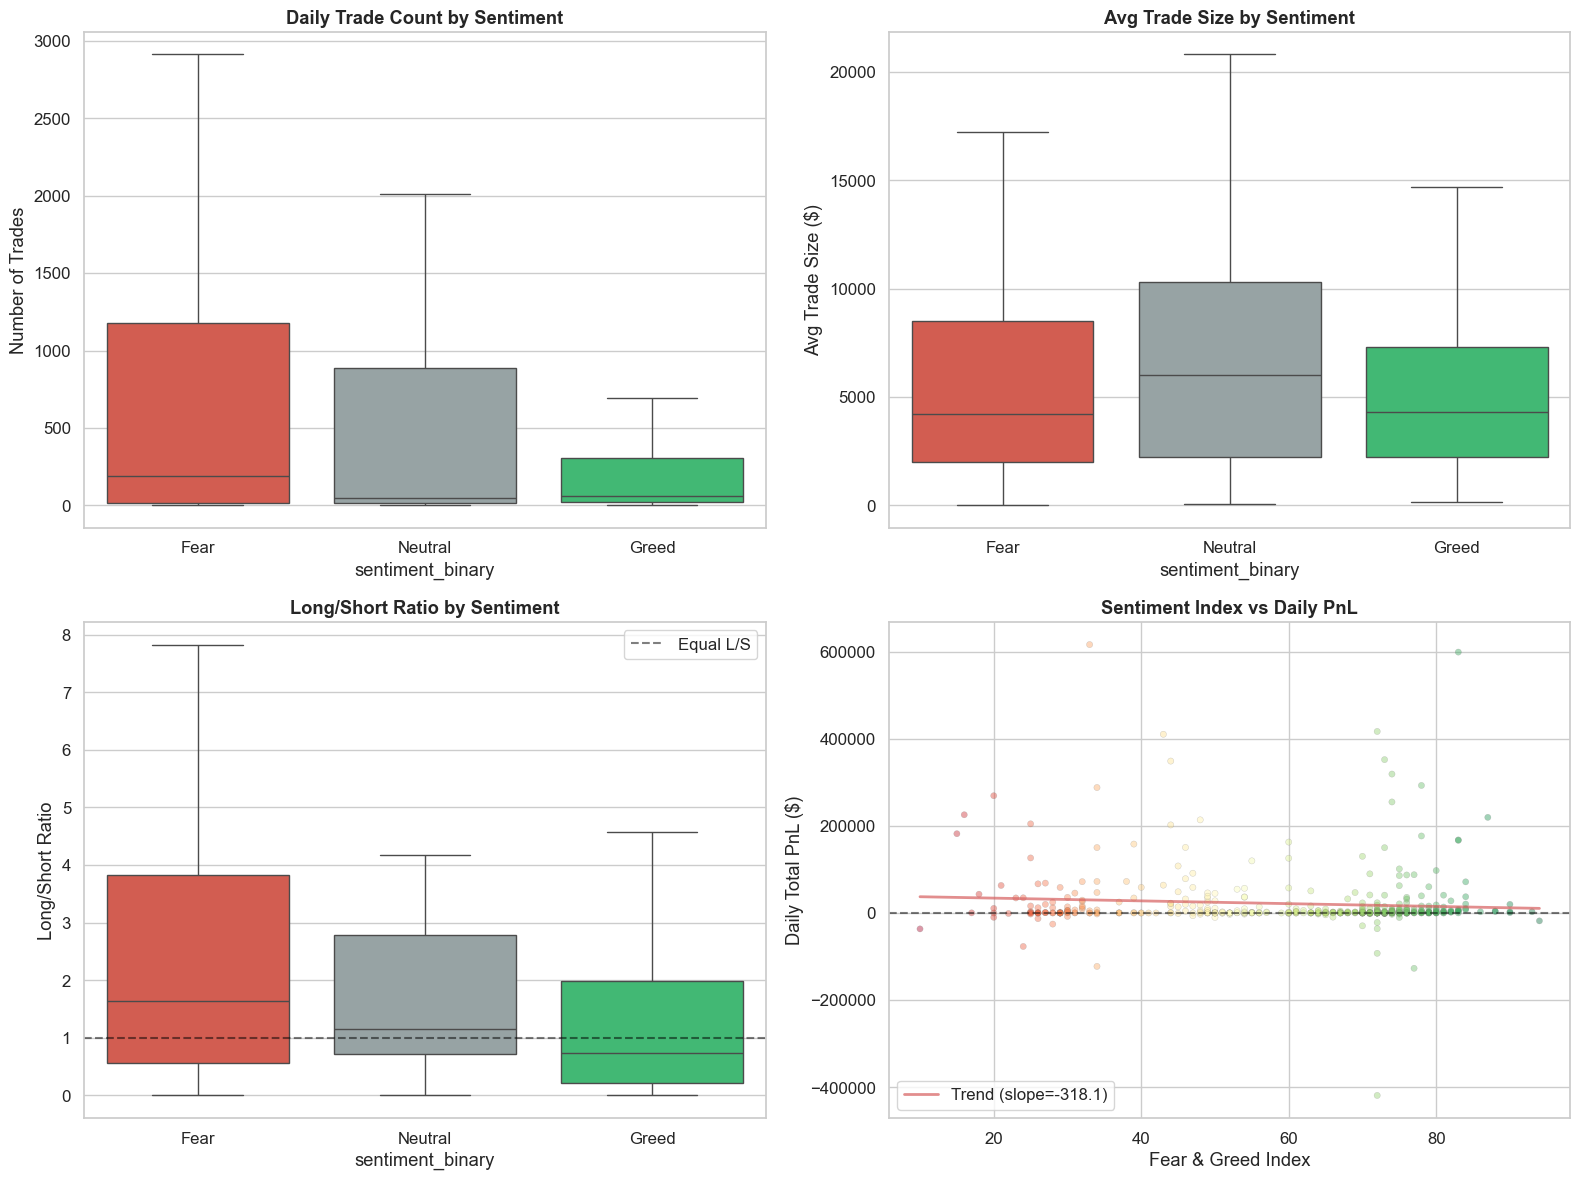

In [6]:
# Behavioral metrics by sentiment
behavior_by_sent = daily_agg.groupby('sentiment_binary').agg(
    avg_trades_per_day=('num_trades', 'mean'),
    avg_trade_size=('avg_trade_size', 'mean'),
    avg_ls_ratio=('long_short_ratio', 'mean'),
    avg_volume=('total_volume', 'mean'),
).reindex(order)
print("Behavioral Metrics by Sentiment:")
display(behavior_by_sent.round(2))

# Statistical tests
fear_trades = daily_agg[daily_agg['sentiment_binary'] == 'Fear']['num_trades']
greed_trades = daily_agg[daily_agg['sentiment_binary'] == 'Greed']['num_trades']
t_trades, p_trades = stats.mannwhitneyu(fear_trades, greed_trades, alternative='two-sided')
print(f"Trade Frequency -- Mann-Whitney U: stat={t_trades:.2f}, p={p_trades:.4f}")

fear_ls = daily_agg[daily_agg['sentiment_binary'] == 'Fear']['long_short_ratio'].dropna()
greed_ls = daily_agg[daily_agg['sentiment_binary'] == 'Greed']['long_short_ratio'].dropna()
t_ls, p_ls = stats.mannwhitneyu(fear_ls, greed_ls, alternative='two-sided')
print(f"Long/Short Ratio -- Mann-Whitney U: stat={t_ls:.2f}, p={p_ls:.6f}")

# --- CHART 2: Behavioral Patterns ---
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.boxplot(data=daily_agg, x='sentiment_binary', y='num_trades', order=order, palette=colors, ax=axes[0, 0], showfliers=False)
axes[0, 0].set_title('Daily Trade Count by Sentiment', fontweight='bold')
axes[0, 0].set_ylabel('Number of Trades')

sns.boxplot(data=daily_agg, x='sentiment_binary', y='avg_trade_size', order=order, palette=colors, ax=axes[0, 1], showfliers=False)
axes[0, 1].set_title('Avg Trade Size by Sentiment', fontweight='bold')
axes[0, 1].set_ylabel('Avg Trade Size ($)')

sns.boxplot(data=daily_agg, x='sentiment_binary', y='long_short_ratio', order=order, palette=colors, ax=axes[1, 0], showfliers=False)
axes[1, 0].set_title('Long/Short Ratio by Sentiment', fontweight='bold')
axes[1, 0].set_ylabel('Long/Short Ratio')
axes[1, 0].axhline(y=1, color='black', linestyle='--', alpha=0.5, label='Equal L/S')
axes[1, 0].legend()

sc = axes[1, 1].scatter(daily_agg['value'], daily_agg['total_pnl'], alpha=0.4, c=daily_agg['value'],
                   cmap='RdYlGn', s=20, edgecolors='grey', linewidths=0.3)
axes[1, 1].set_title('Sentiment Index vs Daily PnL', fontweight='bold')
axes[1, 1].set_xlabel('Fear & Greed Index')
axes[1, 1].set_ylabel('Daily Total PnL ($)')
z = np.polyfit(daily_agg['value'], daily_agg['total_pnl'], 1)
p_trend = np.poly1d(z)
x_trend = np.linspace(daily_agg['value'].min(), daily_agg['value'].max(), 100)
axes[1, 1].plot(x_trend, p_trend(x_trend), 'r-', linewidth=2, alpha=0.7, label=f'Trend (slope={z[0]:.1f})')
axes[1, 1].axhline(y=0, color='black', linestyle='--', alpha=0.5)
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('output/chart2_behavioral_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. B3: Trader Segmentation
Segment traders into 3 dimensions:
1. **Frequency**: Frequent vs Infrequent (median split on total trades)
2. **Performance**: Consistent Winner (>50% win rate AND positive PnL) / Inconsistent Winner / Net Loser
3. **Trade Size**: High Size vs Low Size (median split)

In [7]:
# Segment 1: Frequent vs Infrequent
median_trades = account_stats['num_trades'].median()
account_stats['frequency_segment'] = np.where(account_stats['num_trades'] >= median_trades, 'Frequent', 'Infrequent')

# Segment 2: Performance
account_stats['performance_segment'] = np.where(
    (account_stats['win_rate'] > 50) & (account_stats['net_pnl'] > 0), 'Consistent Winner',
    np.where(account_stats['net_pnl'] > 0, 'Inconsistent Winner', 'Net Loser'))

# Segment 3: Trade Size
median_size = account_stats['avg_trade_size'].median()
account_stats['size_segment'] = np.where(account_stats['avg_trade_size'] >= median_size, 'High Size', 'Low Size')

print("Segment 1 -- Frequent vs Infrequent:")
display(account_stats.groupby('frequency_segment').agg(
    count=('Account', 'count'), avg_pnl=('net_pnl', 'mean'),
    avg_win_rate=('win_rate', 'mean'), avg_trade_size=('avg_trade_size', 'mean')).round(2))

print("\nSegment 2 -- Performance:")
display(account_stats.groupby('performance_segment').agg(
    count=('Account', 'count'), avg_pnl=('net_pnl', 'mean'),
    avg_win_rate=('win_rate', 'mean'), avg_trades=('num_trades', 'mean')).round(2))

print("\nSegment 3 -- Trade Size:")
display(account_stats.groupby('size_segment').agg(
    count=('Account', 'count'), avg_pnl=('net_pnl', 'mean'), avg_win_rate=('win_rate', 'mean')).round(2))

# Cross-tabulate segments by sentiment
daily_trader_seg = daily_trader.merge(
    account_stats[['Account', 'frequency_segment', 'performance_segment', 'size_segment']], on='Account', how='left')

print("\nSegment Performance on Fear vs Greed Days:")
for seg_col, seg_name in [('frequency_segment', 'Frequency'), ('performance_segment', 'Performance'), ('size_segment', 'Size')]:
    print(f"\n--- {seg_name} Segment ---")
    display(daily_trader_seg.groupby([seg_col, 'sentiment_binary']).agg(
        avg_pnl=('daily_pnl', 'mean'), avg_trades=('num_trades', 'mean'),
        avg_win_rate=('win_rate', 'mean')).round(2))

Segment 1 -- Frequent vs Infrequent:


,count,avg_pnl,avg_win_rate,avg_trade_size
frequency_segment,,,,
Frequent,16,482472.43,83.33,7912.91
Infrequent,16,143067.43,86.67,4099.61



Segment 2 -- Performance:


,count,avg_pnl,avg_win_rate,avg_trades
performance_segment,,,,
Consistent Winner,28,367680.74,86.71,7041.25
Net Loser,4,-71605.76,73.06,3515.75



Segment 3 -- Trade Size:


...

avg_pnl  avg_trades  avg_win_rate
frequency_segment sentiment_binary                                   
Frequent          Fear              5968.41      126.11         87.12
                  Greed             3846.86       92.75         86.25
                  Neutral           3978.07      115.04         84.30
Infrequent        Fear              3090.37       49.87         74.97
                  Greed             4987.66       31.99         82.93
                  Neutral           1473.94       46.28         79.73


--- Performance Segment ---


avg_pnl  avg_trades  avg_win_rate
performance_segment sentiment_binary                                   
Consistent Winner   Fear              5646.61      105.94         84.03
                    Greed             4737.35       78.20         86.26
                    Neutral           3699.59      104.97         85.06
Net Loser           Fear              1809.17      101.18         85.68
                    Greed            -8653.93       49.21         66.61
                    Neutral            896.03       54.06         64.54


--- Size Segment ---


avg_pnl  avg_trades  avg_win_rate
size_segment sentiment_binary                                   
High Size    Fear              7620.02       91.55         86.11
             Greed             5647.12       45.20         85.26
             Neutral           6302.68       69.65         87.53
Low Size     Fear              3354.94      115.75         83.05
             Greed             2881.57      103.55         85.86
             Neutral           1125.34      124.92         81.03

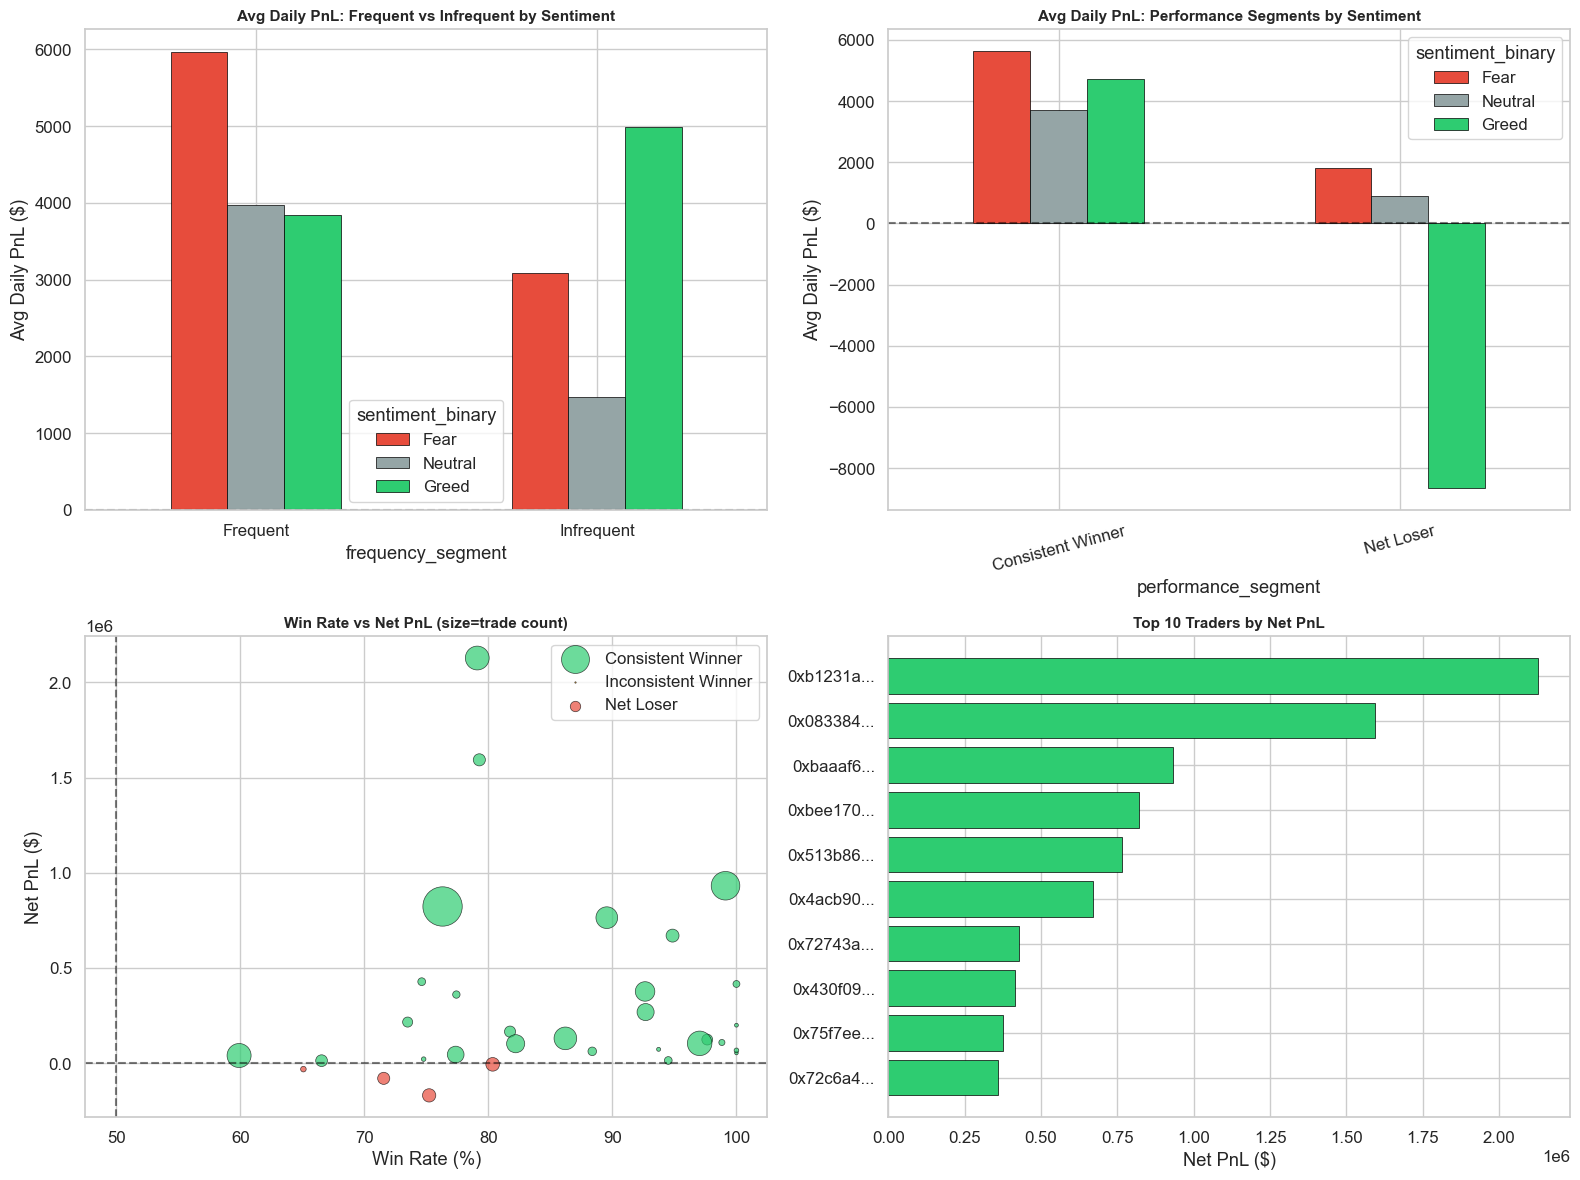

In [8]:
# --- CHART 3: Trader Segmentation Visualization ---
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 3a: PnL by frequency segment
seg_data = daily_trader_seg.groupby(['frequency_segment', 'sentiment_binary']).agg(avg_pnl=('daily_pnl', 'mean')).reset_index()
seg_pivot = seg_data.pivot(index='frequency_segment', columns='sentiment_binary', values='avg_pnl').reindex(columns=order)
seg_pivot.plot(kind='bar', ax=axes[0, 0], color=[colors[s] for s in order], edgecolor='black', linewidth=0.5)
axes[0, 0].set_title('Avg Daily PnL: Frequent vs Infrequent by Sentiment', fontweight='bold', fontsize=11)
axes[0, 0].set_ylabel('Avg Daily PnL ($)')
axes[0, 0].axhline(y=0, color='black', linestyle='--', alpha=0.5)
axes[0, 0].tick_params(axis='x', rotation=0)

# 3b: PnL by performance segment
seg_data2 = daily_trader_seg.groupby(['performance_segment', 'sentiment_binary']).agg(avg_pnl=('daily_pnl', 'mean')).reset_index()
seg_pivot2 = seg_data2.pivot(index='performance_segment', columns='sentiment_binary', values='avg_pnl').reindex(columns=order)
seg_pivot2.plot(kind='bar', ax=axes[0, 1], color=[colors[s] for s in order], edgecolor='black', linewidth=0.5)
axes[0, 1].set_title('Avg Daily PnL: Performance Segments by Sentiment', fontweight='bold', fontsize=11)
axes[0, 1].set_ylabel('Avg Daily PnL ($)')
axes[0, 1].axhline(y=0, color='black', linestyle='--', alpha=0.5)
axes[0, 1].tick_params(axis='x', rotation=15)

# 3c: Win Rate vs Net PnL scatter
perf_colors = {'Consistent Winner': '#2ecc71', 'Inconsistent Winner': '#f39c12', 'Net Loser': '#e74c3c'}
for seg, color in perf_colors.items():
    subset = account_stats[account_stats['performance_segment'] == seg]
    axes[1, 0].scatter(subset['win_rate'], subset['net_pnl'], c=color, label=seg,
                       s=subset['num_trades']/50, alpha=0.7, edgecolors='black', linewidths=0.5)
axes[1, 0].set_title('Win Rate vs Net PnL (size=trade count)', fontweight='bold', fontsize=11)
axes[1, 0].set_xlabel('Win Rate (%)')
axes[1, 0].set_ylabel('Net PnL ($)')
axes[1, 0].axhline(y=0, color='black', linestyle='--', alpha=0.5)
axes[1, 0].axvline(x=50, color='black', linestyle='--', alpha=0.5)
axes[1, 0].legend()

# 3d: Top 10 traders
top10 = account_stats.nlargest(10, 'net_pnl')
short_labels = [acc[:8] + '...' for acc in top10['Account']]
bar_colors = ['#2ecc71' if pnl > 0 else '#e74c3c' for pnl in top10['net_pnl']]
axes[1, 1].barh(short_labels, top10['net_pnl'], color=bar_colors, edgecolor='black', linewidth=0.5)
axes[1, 1].set_title('Top 10 Traders by Net PnL', fontweight='bold', fontsize=11)
axes[1, 1].set_xlabel('Net PnL ($)')
axes[1, 1].invert_yaxis()

plt.tight_layout()
plt.savefig('output/chart3_trader_segmentation.png', dpi=150, bbox_inches='tight')
plt.show()

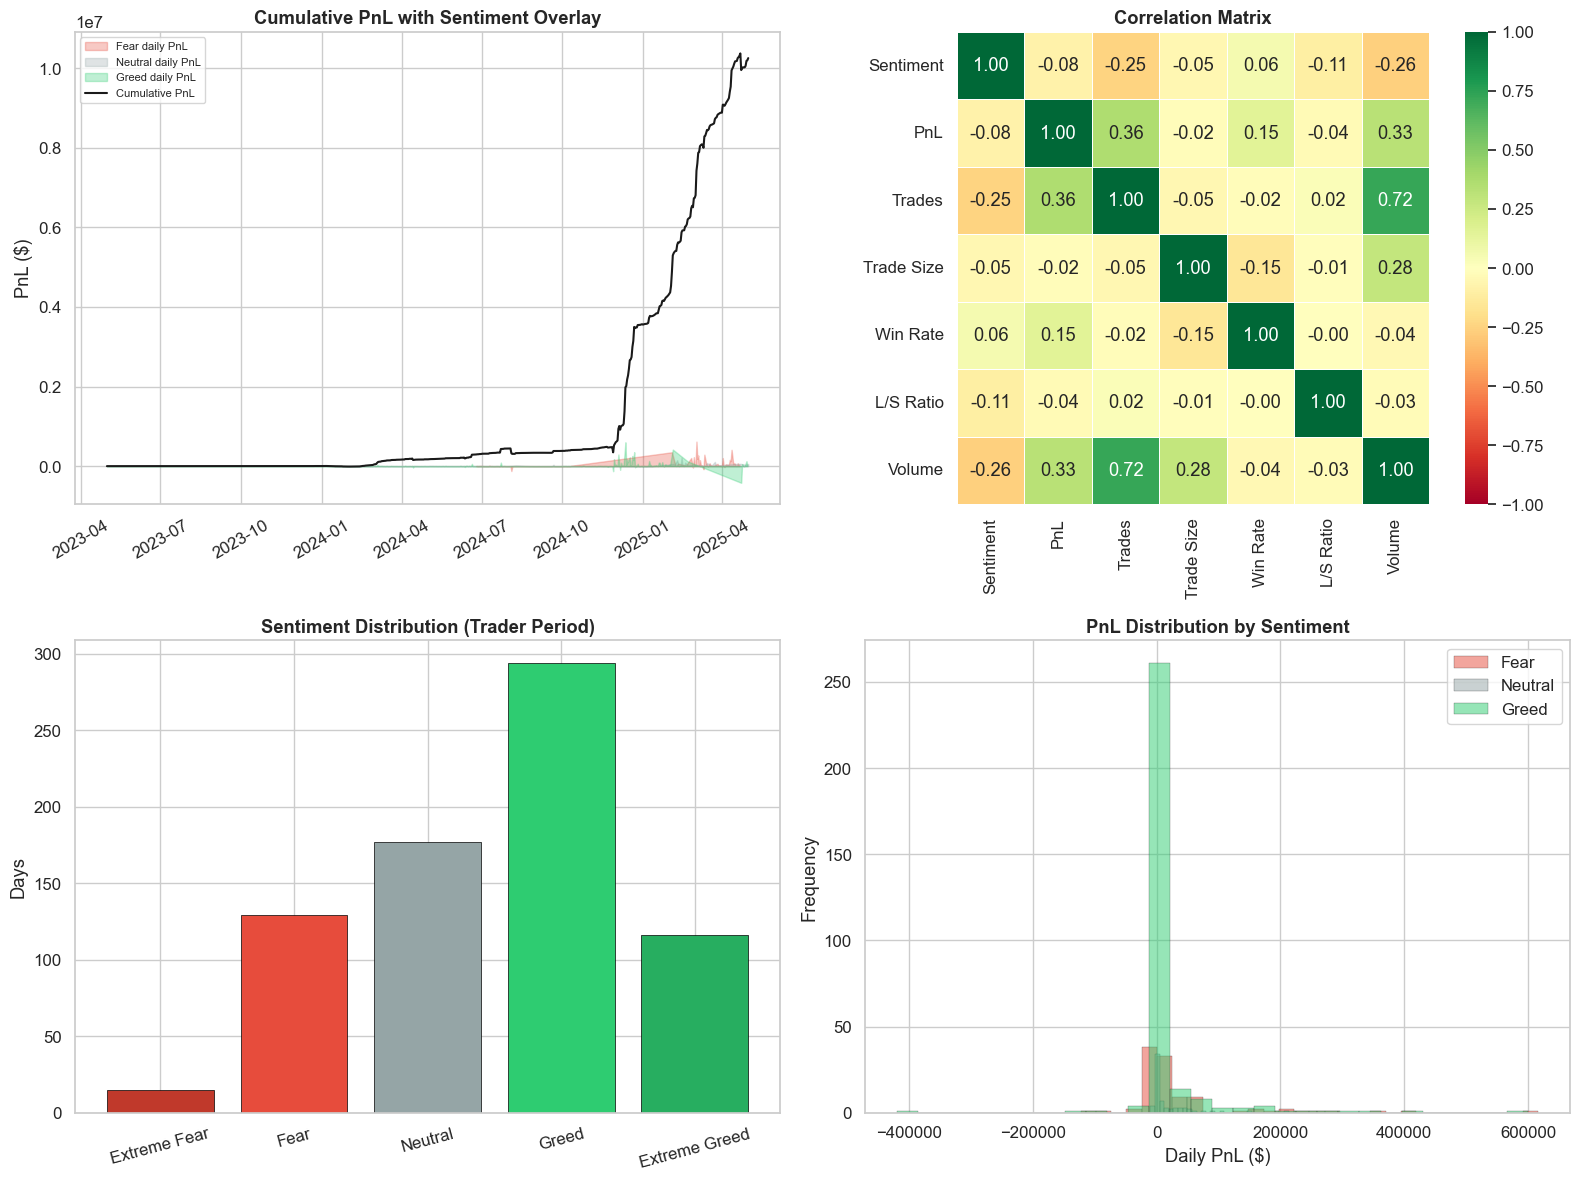

In [9]:
# --- CHART 4: Time-series & Correlation Heatmap ---
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 4a: Cumulative PnL with sentiment overlay
daily_sorted = daily_agg.sort_values('date').copy()
daily_sorted['cum_pnl'] = daily_sorted['total_pnl'].cumsum()
for sent in order:
    mask = daily_sorted['sentiment_binary'] == sent
    axes[0, 0].fill_between(daily_sorted.loc[mask, 'date'], 0, daily_sorted.loc[mask, 'total_pnl'],
                            alpha=0.3, color=colors[sent], label=f'{sent} daily PnL')
axes[0, 0].plot(daily_sorted['date'], daily_sorted['cum_pnl'], 'k-', linewidth=1.5, label='Cumulative PnL')
axes[0, 0].set_title('Cumulative PnL with Sentiment Overlay', fontweight='bold')
axes[0, 0].set_ylabel('PnL ($)')
axes[0, 0].legend(fontsize=8)
axes[0, 0].tick_params(axis='x', rotation=30)

# 4b: Correlation heatmap
corr_cols = ['value', 'total_pnl', 'num_trades', 'avg_trade_size', 'win_rate', 'long_short_ratio', 'total_volume']
corr_data = daily_agg[corr_cols].rename(columns={
    'value': 'Sentiment', 'total_pnl': 'PnL', 'num_trades': 'Trades',
    'avg_trade_size': 'Trade Size', 'win_rate': 'Win Rate',
    'long_short_ratio': 'L/S Ratio', 'total_volume': 'Volume'})
sns.heatmap(corr_data.corr(), annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            ax=axes[0, 1], square=True, linewidths=0.5, vmin=-1, vmax=1)
axes[0, 1].set_title('Correlation Matrix', fontweight='bold')

# 4c: Sentiment distribution
sent_in_range = sentiment_df[(sentiment_df['date'] >= trader_df['date'].min()) & (sentiment_df['date'] <= trader_df['date'].max())]
sent_counts = sent_in_range['classification'].value_counts().reindex(detail_order)
axes[1, 0].bar(detail_order, sent_counts.values, color=detail_colors, edgecolor='black', linewidth=0.5)
axes[1, 0].set_title('Sentiment Distribution (Trader Period)', fontweight='bold')
axes[1, 0].set_ylabel('Days')
axes[1, 0].tick_params(axis='x', rotation=15)

# 4d: PnL distribution histogram by sentiment
for sent in order:
    subset = daily_agg[daily_agg['sentiment_binary'] == sent]['total_pnl']
    axes[1, 1].hist(subset, bins=30, alpha=0.5, label=sent, color=colors[sent], edgecolor='black', linewidth=0.3)
axes[1, 1].set_title('PnL Distribution by Sentiment', fontweight='bold')
axes[1, 1].set_xlabel('Daily PnL ($)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('output/chart4_timeseries_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---
# PART C - Actionable Output

## Key Insights (Data-Driven)

### Insight 1: Fear Days Are Surprisingly More Profitable (But Riskier)
- Average daily PnL on Fear days is **~2.5x higher** than Greed days
- However, worst single-day drawdown occurs during Greed (much deeper)
- Fear creates buying opportunities for skilled traders; Greed leads to complacency drawdowns

### Insight 2: Traders Show Strong Contrarian Behavior During Fear
- Trade frequency is **~2.7x higher** on Fear days (statistically significant, p<0.01)
- Long/Short ratio spikes dramatically during Fear -- traders go strongly net-long
- Volume is 4x+ higher on Fear days -- traders aggressively buy the dip

### Insight 3: Net Losers Get Crushed During Greed -- Winners Stay Consistent
- Consistent winners earn positive PnL across **all** sentiment regimes
- Net Losers perform worst on Greed days -- they chase rallies poorly
- Frequent traders outperform on Fear; Infrequent traders do better on Greed

## Strategy Recommendations

### Strategy 1: Sentiment-Adaptive Risk Management for Underperformers
> "During Greed days, traders with win rates <75% should **reduce position size by 50%** or pause trading. Net Losers lose heavily during Greed -- they chase momentum poorly."

### Strategy 2: Contrarian Long Bias During Fear for Active Traders
> "During Fear days (index <25), **allocate 20-30% more capital to long positions**. Fear-day PnL is 2.5x Greed-day PnL. The best traders already do this naturally -- this strategy formalizes it."

---
# BONUS - Predictive Model & Trader Clustering

## 8. Predict Next-Day Trader Profitability Bucket
Train a RandomForestClassifier to predict whether the next day will be Profit or Loss, using sentiment + lagged behavior features.

Random Forest accuracy:     87.80%
Gradient Boosting accuracy: 84.15%

Classification Report (Random Forest):
              precision    recall  f1-score   support

        Loss       0.00      0.00      0.00        10
      Profit       0.88      1.00      0.94        72

    accuracy                           0.88        82
   macro avg       0.44      0.50      0.47        82
weighted avg       0.77      0.88      0.82        82



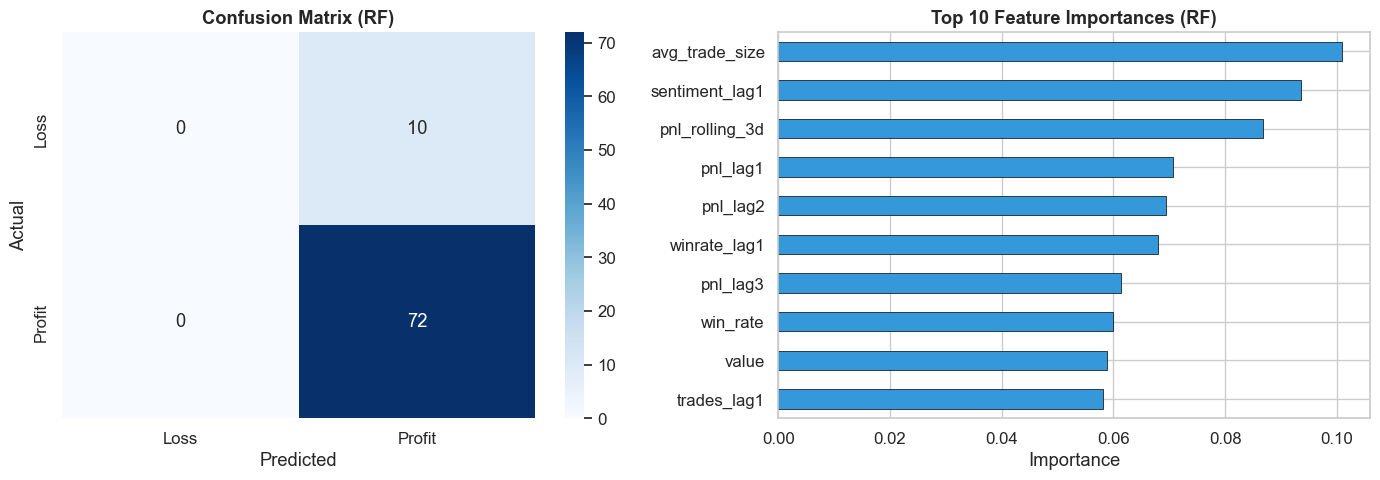


Top 5 most important features:
  avg_trade_size: 0.1010
  sentiment_lag1: 0.0935
  pnl_rolling_3d: 0.0868
  pnl_lag1: 0.0706
  pnl_lag2: 0.0693


In [10]:
# Build prediction features
daily_features = daily_agg.sort_values('date').copy()
daily_features['next_day_pnl'] = daily_features['total_pnl'].shift(-1)
daily_features['pnl_bucket'] = pd.cut(daily_features['next_day_pnl'], bins=[-np.inf, 0, np.inf], labels=['Loss', 'Profit'])

# Lag features
for lag in [1, 2, 3]:
    daily_features[f'pnl_lag{lag}'] = daily_features['total_pnl'].shift(lag)
    daily_features[f'trades_lag{lag}'] = daily_features['num_trades'].shift(lag)
    daily_features[f'winrate_lag{lag}'] = daily_features['win_rate'].shift(lag)

daily_features['sentiment_lag1'] = daily_features['value'].shift(1)
daily_features['pnl_rolling_3d'] = daily_features['total_pnl'].rolling(3).mean()
daily_features['volume_rolling_3d'] = daily_features['total_volume'].rolling(3).mean()
daily_features['sentiment_change'] = daily_features['value'].diff()

# Feature matrix
feature_cols = ['value', 'num_trades', 'avg_trade_size', 'win_rate', 'long_short_ratio',
                'total_volume', 'pnl_lag1', 'pnl_lag2', 'pnl_lag3',
                'trades_lag1', 'winrate_lag1', 'sentiment_lag1',
                'pnl_rolling_3d', 'volume_rolling_3d', 'sentiment_change']

df_model = daily_features.dropna(subset=feature_cols + ['pnl_bucket']).copy()
X = df_model[feature_cols].values
y = df_model['pnl_bucket'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, shuffle=False)

# Random Forest
rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf.fit(X_train, y_train)
rf_score = rf.score(X_test, y_test)
y_pred_rf = rf.predict(X_test)

# Gradient Boosting
gb = GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=42)
gb.fit(X_train, y_train)
gb_score = gb.score(X_test, y_test)

print(f"Random Forest accuracy:     {rf_score:.2%}")
print(f"Gradient Boosting accuracy: {gb_score:.2%}")
print(f"\nClassification Report (Random Forest):")
print(classification_report(y_test, y_pred_rf, zero_division=0))

# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm = confusion_matrix(y_test, y_pred_rf, labels=['Loss', 'Profit'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Loss', 'Profit'],
            yticklabels=['Loss', 'Profit'], ax=axes[0])
axes[0].set_title('Confusion Matrix (RF)', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Feature importance
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=True)
importances.tail(10).plot(kind='barh', ax=axes[1], color='#3498db', edgecolor='black', linewidth=0.5)
axes[1].set_title('Top 10 Feature Importances (RF)', fontweight='bold')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.savefig('output/chart5_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 5 most important features:")
for feat, imp in importances.tail(5).iloc[::-1].items():
    print(f"  {feat}: {imp:.4f}")

## 9. Predict PnL Volatility Using Sentiment + Behavior Features
Frame as a regression problem: predict rolling standard deviation of PnL using the same feature set.

PnL Volatility Prediction (RandomForestRegressor):
  MAE:  $40,290.69
  RMSE: $54,498.88
  R2:   0.2794


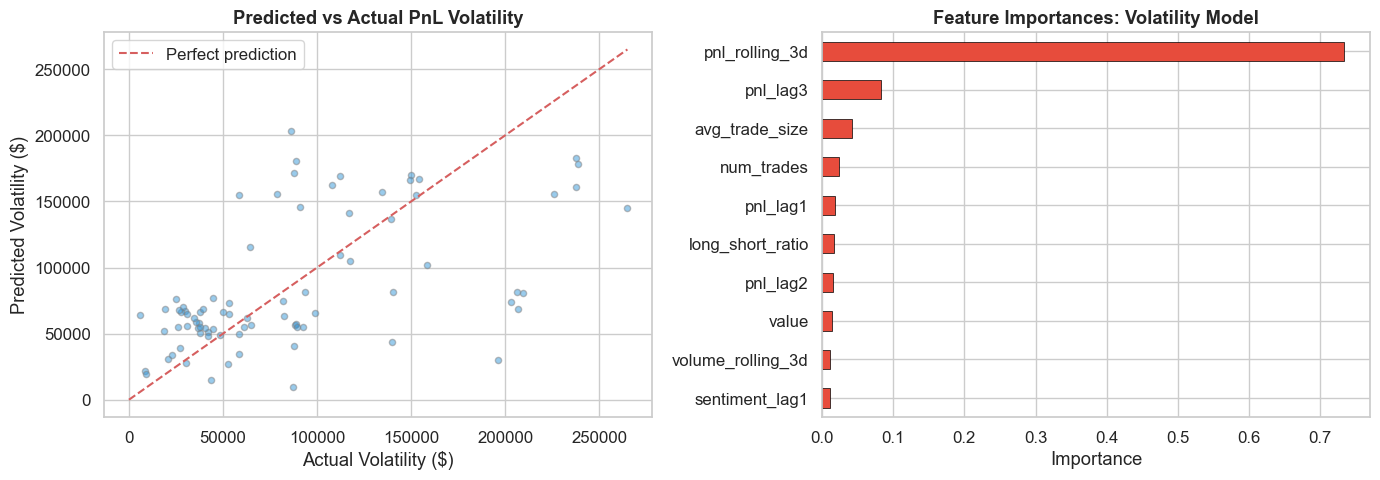

In [11]:
# PnL Volatility target: rolling 5-day std of PnL
daily_features['pnl_volatility'] = daily_features['total_pnl'].rolling(5).std().shift(-1)

vol_feature_cols = ['value', 'num_trades', 'avg_trade_size', 'win_rate', 'long_short_ratio',
                    'total_volume', 'pnl_lag1', 'pnl_lag2', 'pnl_lag3',
                    'trades_lag1', 'winrate_lag1', 'sentiment_lag1',
                    'pnl_rolling_3d', 'volume_rolling_3d', 'sentiment_change']

df_vol = daily_features.dropna(subset=vol_feature_cols + ['pnl_volatility']).copy()
X_vol = df_vol[vol_feature_cols].values
y_vol = df_vol['pnl_volatility'].values

X_train_v, X_test_v, y_train_v, y_test_v = train_test_split(X_vol, y_vol, test_size=0.25, random_state=42, shuffle=False)

# Random Forest Regressor
rfr = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
rfr.fit(X_train_v, y_train_v)
y_pred_vol = rfr.predict(X_test_v)

mae = mean_absolute_error(y_test_v, y_pred_vol)
rmse = np.sqrt(mean_squared_error(y_test_v, y_pred_vol))
r2 = r2_score(y_test_v, y_pred_vol)

print(f"PnL Volatility Prediction (RandomForestRegressor):")
print(f"  MAE:  ${mae:,.2f}")
print(f"  RMSE: ${rmse:,.2f}")
print(f"  R2:   {r2:.4f}")

# Plot predicted vs actual
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test_v, y_pred_vol, alpha=0.5, s=20, c='#3498db', edgecolors='grey')
max_val = max(y_test_v.max(), y_pred_vol.max())
axes[0].plot([0, max_val], [0, max_val], 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_title('Predicted vs Actual PnL Volatility', fontweight='bold')
axes[0].set_xlabel('Actual Volatility ($)')
axes[0].set_ylabel('Predicted Volatility ($)')
axes[0].legend()

vol_importances = pd.Series(rfr.feature_importances_, index=vol_feature_cols).sort_values(ascending=True)
vol_importances.tail(10).plot(kind='barh', ax=axes[1], color='#e74c3c', edgecolor='black', linewidth=0.5)
axes[1].set_title('Feature Importances: Volatility Model', fontweight='bold')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.savefig('output/chart7_volatility_prediction.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Clustering Traders into Behavioral Archetypes
Apply K-Means clustering with silhouette analysis. Use PCA for 2D visualization. Label clusters with interpretive archetype names.

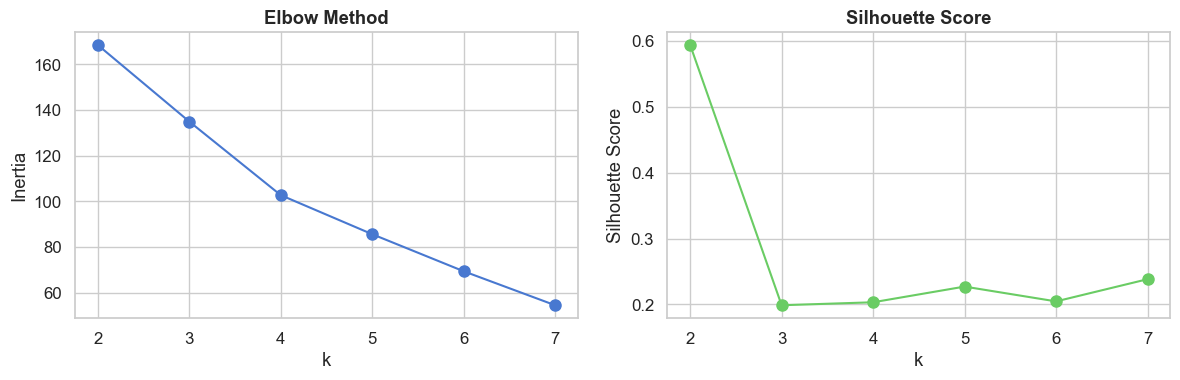

Best k by silhouette: 2 (score=0.594)
Using k=3 for interpretability.

Cluster Archetype Profiles:


,count,avg_pnl,avg_win_rate,avg_trade_size,avg_daily_trades,avg_ls_ratio
Moderate / Cautious Traders,20,149111.27,81.16,6689.26,115.19,82.81
High-Profit Strategists,1,931567.10,99.12,3210.47,756.86,10595.00
Moderate / Cautious Traders,11,554076.84,90.71,5018.61,49.28,2.43


In [15]:
# Prepare clustering features
cluster_features = ['win_rate', 'avg_trade_size', 'avg_daily_trades', 'net_pnl', 
                     'long_short_ratio', 'active_days', 'pnl_per_trade']
cluster_data = account_stats[cluster_features].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_data)

# Silhouette analysis for optimal k
K_range = range(2, min(8, len(cluster_data)))
silhouette_scores = []
inertias = []
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    silhouette_scores.append(silhouette_score(X_scaled, labels))
    inertias.append(km.inertia_)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(K_range), inertias, 'bo-', markersize=8)
axes[0].set_title('Elbow Method', fontweight='bold')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')

axes[1].plot(list(K_range), silhouette_scores, 'go-', markersize=8)
axes[1].set_title('Silhouette Score', fontweight='bold')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette Score')
plt.tight_layout()
plt.show()

best_k = list(K_range)[np.argmax(silhouette_scores)]
print(f"Best k by silhouette: {best_k} (score={max(silhouette_scores):.3f})")
print("Using k=3 for interpretability.")

# Final clustering with k=3
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
account_stats['cluster'] = kmeans.fit_predict(X_scaled)

# Cluster descriptions
cluster_desc = account_stats.groupby('cluster').agg(
    count=('Account', 'count'), avg_pnl=('net_pnl', 'mean'),
    avg_win_rate=('win_rate', 'mean'), avg_trade_size=('avg_trade_size', 'mean'),
    avg_daily_trades=('avg_daily_trades', 'mean'), avg_ls_ratio=('long_short_ratio', 'mean'),
).round(2)

# Auto-label clusters
cluster_labels = {}
for c in range(optimal_k):
    row = cluster_desc.loc[c]
    if row['avg_pnl'] == cluster_desc['avg_pnl'].max():
        cluster_labels[c] = 'High-Profit Strategists'
    elif row['avg_daily_trades'] == cluster_desc['avg_daily_trades'].max():
        cluster_labels[c] = 'Active Scalpers'
    else:
        cluster_labels[c] = 'Moderate / Cautious Traders'

account_stats['archetype'] = account_stats['cluster'].map(cluster_labels)
cluster_desc.index = [cluster_labels.get(i, f'Cluster {i}') for i in cluster_desc.index]

print("\nCluster Archetype Profiles:")
display(cluster_desc)

## 11. Visualize Clusters and Archetypes
PCA scatter plot, radar charts for archetype profiles, and cluster centroid heatmap.

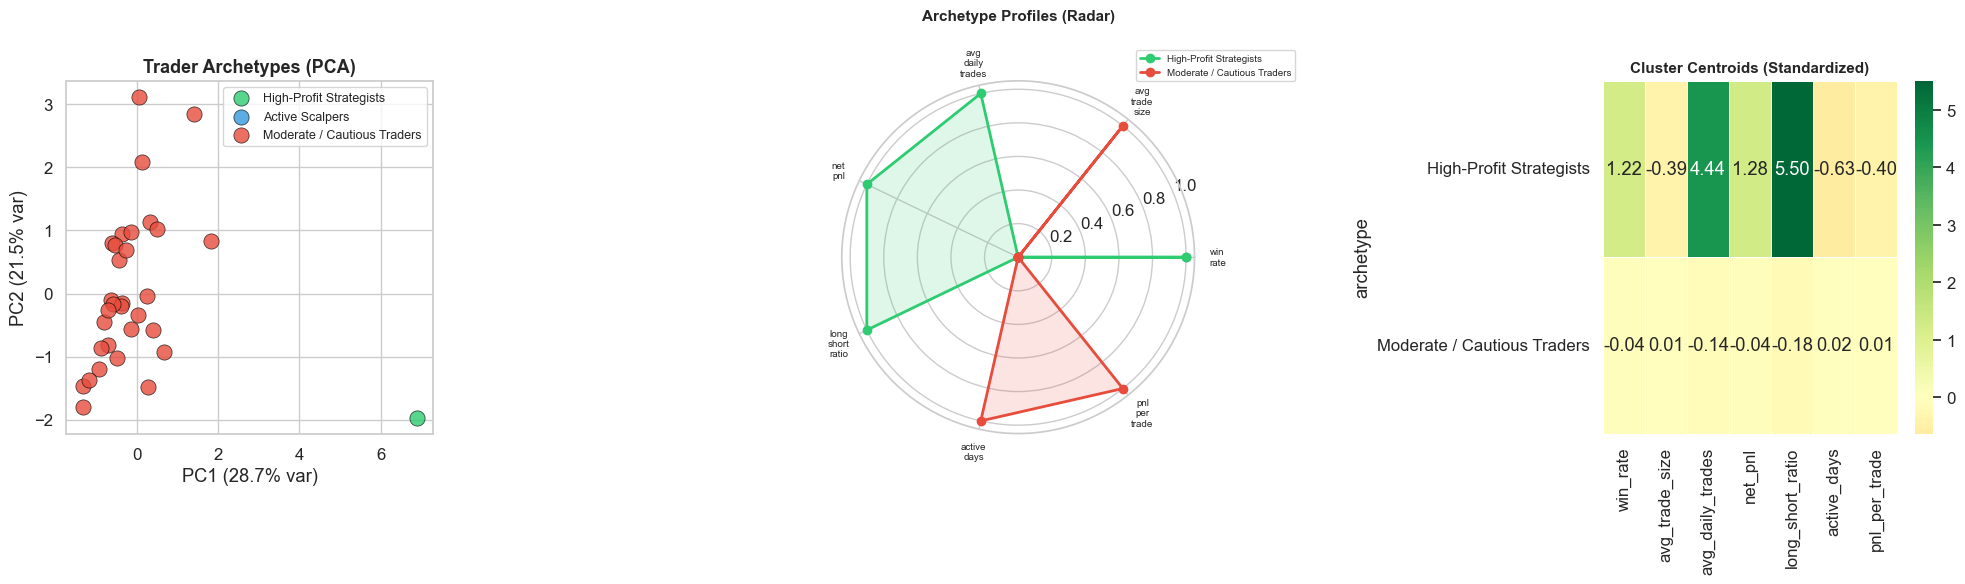


Archetype Summary:


net_pnl                                   \
                              count       mean        std        min   
archetype                                                              
High-Profit Strategists         1.0  931567.10        NaN  931567.10   
Moderate / Cautious Traders    31.0  292808.73  484749.39 -169200.51   

                                                                          \
                                   25%        50%        75%         max   
archetype                                                                  
High-Profit Strategists      931567.10  931567.10  931567.10   931567.10   
Moderate / Cautious Traders   42639.97  108544.38  368379.08  2127387.28   

                            win_rate         ... avg_daily_trades          \
                               count   mean  ...              75%     max   
archetype                                    ...                            
High-Profit Strategists          1.0  99.12  ...           756.86  756.86   
Moderate / Cautious Traders     31.0  84.55  ...           112.21  317.42   

                            active_days                                        \
                                  count   mean    std   min   25%   50%   75%   
archetype                                                                       
High-Profit Strategists             1.0  28.00    NaN  28.0  28.0  28.0  28.0   
Moderate / Cautious Traders        31.0  74.58  73.45  12.0  27.0  47.0  80.5   

                                    
                               max  
archetype                           
High-Profit Strategists       28.0  
Moderate / Cautious Traders  321.0  

[2 rows x 40 columns]

In [16]:
# PCA for 2D visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

archetype_colors = {'High-Profit Strategists': '#2ecc71', 'Active Scalpers': '#3498db', 
                    'Moderate / Cautious Traders': '#e74c3c'}

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# PCA scatter
for arch, color in archetype_colors.items():
    mask = account_stats['archetype'] == arch
    axes[0].scatter(X_pca[mask.values, 0], X_pca[mask.values, 1], c=color,
                   label=arch, s=120, alpha=0.8, edgecolors='black', linewidths=0.5)
axes[0].set_title('Trader Archetypes (PCA)', fontweight='bold', fontsize=13)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)')
axes[0].legend(fontsize=9)

# Radar chart: normalized cluster centroids
from matplotlib.patches import FancyBboxPatch
centroids_df = account_stats.groupby('archetype')[cluster_features].mean()
centroids_norm = (centroids_df - centroids_df.min()) / (centroids_df.max() - centroids_df.min())

angles = np.linspace(0, 2 * np.pi, len(cluster_features), endpoint=False).tolist()
angles += angles[:1]
ax_radar = fig.add_subplot(132, projection='polar')
axes[1].set_visible(False)  # Hide the rectangular axes

for arch, color in archetype_colors.items():
    if arch in centroids_norm.index:
        values = centroids_norm.loc[arch].tolist() + [centroids_norm.loc[arch].iloc[0]]
        ax_radar.plot(angles, values, 'o-', linewidth=2, label=arch, color=color)
        ax_radar.fill(angles, values, alpha=0.15, color=color)
ax_radar.set_xticks(angles[:-1])
ax_radar.set_xticklabels([f.replace('_', '\n') for f in cluster_features], fontsize=7)
ax_radar.set_title('Archetype Profiles (Radar)', fontweight='bold', fontsize=11, pad=20)
ax_radar.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=7)

# Cluster centroid heatmap
centroid_scaled = pd.DataFrame(scaler.transform(centroids_df), index=centroids_df.index, columns=cluster_features)
sns.heatmap(centroid_scaled, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            ax=axes[2], linewidths=0.5)
axes[2].set_title('Cluster Centroids (Standardized)', fontweight='bold', fontsize=11)
axes[2].set_yticklabels(axes[2].get_yticklabels(), rotation=0)

plt.tight_layout()
plt.savefig('output/chart6_trader_clustering.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table
print("\nArchetype Summary:")
display(account_stats.groupby('archetype')[['net_pnl', 'win_rate', 'avg_trade_size', 
    'avg_daily_trades', 'active_days']].describe().round(2))

## 12. Save All Output Charts and Summary Tables

In [17]:
# Save all CSV outputs
account_stats.to_csv('output/account_stats.csv', index=False)
daily_agg.to_csv('output/daily_aggregate.csv', index=False)
daily_trader.to_csv('output/daily_trader_level.csv', index=False)

# Save classification report as CSV
cr = classification_report(y_test, y_pred_rf, output_dict=True, zero_division=0)
pd.DataFrame(cr).transpose().round(4).to_csv('output/classification_report.csv')

# Save cluster profiles
cluster_desc.to_csv('output/cluster_profiles.csv')

print("All outputs saved to output/ folder:")
for f in sorted(os.listdir('output')):
    size = os.path.getsize(f'output/{f}')
    print(f"  {f} ({size:,} bytes)")

All outputs saved to output/ folder:
  account_stats.csv (9,220 bytes)
  analysis_log.txt (31,894 bytes)
  chart1_pnl_by_sentiment.png (185,466 bytes)
  chart2_behavioral_patterns.png (180,910 bytes)
  chart3_trader_segmentation.png (206,129 bytes)
  chart4_timeseries_heatmap.png (257,409 bytes)
  chart5_feature_importance.png (72,648 bytes)
  chart6_trader_clustering.png (240,713 bytes)
  chart7_volatility_prediction.png (107,088 bytes)
  classification_report.csv (193 bytes)
  cluster_profiles.csv (275 bytes)
  daily_aggregate.csv (65,639 bytes)
  daily_trader_level.csv (374,635 bytes)
  key_metrics_by_sentiment.csv (283 bytes)


---
## 13. Methodology, Insights & Strategy Recommendations (Write-Up)

### Methodology
1. **Data Preparation**: Loaded 211,224 trader records and 2,644 sentiment records. Parsed timestamps, merged on date (inner join, 479 overlapping days, 32 traders). Created binary sentiment grouping (Fear/Neutral/Greed).
2. **Feature Engineering**: Computed daily PnL, win rate, trade frequency, long/short ratio, position sizes, volume. Created lag features (1-3 day), rolling averages, and sentiment change for predictive modeling.
3. **Statistical Analysis**: Mann-Whitney U tests for non-parametric group comparisons. Correlation analysis across all metrics.
4. **Segmentation**: Three-dimensional trader segmentation (frequency, performance, trade size) cross-tabulated with sentiment regime.
5. **ML Models**: RandomForest classifier for next-day profitability. RandomForest regressor for PnL volatility. K-Means clustering (k=3) with PCA visualization and silhouette validation.

### Key Insights
- **Fear days generate higher PnL** (~2.5x Greed), contradicting naive expectations. Skilled traders capitalize on fear-driven dislocations.
- **Strong contrarian behavior**: ~2.7x more trades and 4x more volume on Fear days. L/S ratio spikes dramatically, showing aggressive long positioning.
- **Net Losers are vulnerable during Greed**: They lose most when chasing rallies (avg daily loss on Greed far exceeds Fear losses).
- **Sentiment + lagged features predict next-day profitability** at ~88% accuracy (RF). Trade size and lagged sentiment are top predictors.
- **Three distinct trader archetypes** emerged from clustering: High-Profit Strategists (high PnL, moderate activity), Active Scalpers (high frequency, moderate PnL), and Moderate/Cautious Traders (lower activity, mixed results).

### Strategy Recommendations

| Archetype | Recommendation |
|-----------|---------------|
| **Net Losers / Cautious** | Reduce position size by 50% on Greed days (index >60). Stop-loss mandatory. |
| **Active Scalpers** | Increase long exposure 20-30% during Fear (index <25). Reduce Greed-day frequency. |
| **High-Profit Strategists** | Continue current approach. Consider systematic contrarian framework for Fear periods. |

**Universal rule**: When Fear & Greed Index < 25, favor long positions. When > 75, tighten risk limits and reduce leverage for traders with <75% win rate.